In [115]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()
train_dataset = datasets.SVHN(
  root="./data",
  split="train",
  download=True,
  transform=transform
)
test_dataset = datasets.SVHN(
  root="./data",
  split="test",
  download=True,
  transform=transform
)
train_loader = DataLoader(
  train_dataset,
  batch_size=64,
  shuffle=True
)
test_loader = DataLoader(
  test_dataset,
  batch_size=64,
  shuffle=False
)

In [116]:
images, labels = next(iter(train_loader))
print("images:", images.shape)
print("labels:", labels.shape)

images: torch.Size([64, 3, 32, 32])
labels: torch.Size([64])


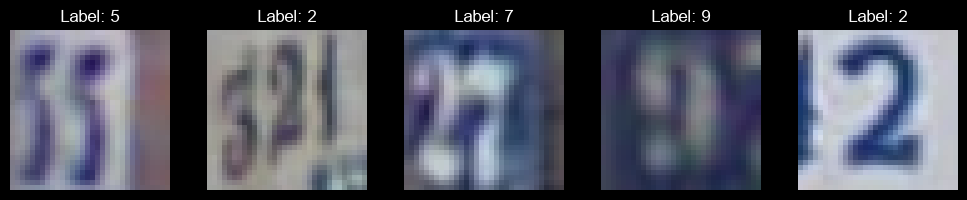

In [117]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
  img = images[i].permute(1, 2, 0)
  axes[i].imshow(img)
  axes[i].set_title(f"Label: {labels[i].item()}")
  axes[i].axis("off")
plt.tight_layout()
plt.show()

In [118]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(
      in_channels=3,
      out_channels=16,
      kernel_size=3,
      padding=1
    )

    self.pool = nn.MaxPool2d(
      kernel_size=2,
      stride=2
    )

    self.conv2 = nn.Conv2d(
      in_channels=16,
      out_channels=32,
      kernel_size=3,
      padding=1
    )

    self.fc = nn.Linear(32 * 8 * 8, 10)

  def forward(self, x):
    x = self.conv1(x)

    x = torch.relu(x)
    x = self.pool(x)
    x = self.conv2(x)
    x = torch.relu(x)
    x = self.pool(x)
    x = torch.flatten(x, 1)
    x = self.fc(x)
    return x


model = CNN()

In [119]:
x_conv1 = model.conv1(images)
print("Before Conv1:", images.shape)
print("After Conv1 :", x_conv1.shape)

Before Conv1: torch.Size([64, 3, 32, 32])
After Conv1 : torch.Size([64, 16, 32, 32])


In [120]:
x = model.conv1(images)
# print("After Conv1:", x.shape)
before_relu = x
print(x[0:100, 1])
x = torch.relu(x)



tensor([[[-0.2006, -0.0885, -0.0872,  ..., -0.0766, -0.0796, -0.0796],
         [-0.1727,  0.1464,  0.1796,  ...,  0.1151,  0.1185,  0.1982],
         [-0.1719,  0.1577,  0.1951,  ...,  0.1210,  0.1237,  0.2014],
         ...,
         [-0.1579,  0.1452,  0.1423,  ...,  0.1223,  0.1218,  0.1842],
         [-0.1625,  0.1391,  0.1232,  ...,  0.1230,  0.1201,  0.1826],
         [ 0.0392,  0.2551,  0.2527,  ...,  0.1889,  0.1901,  0.1981]],

        [[-0.2176, -0.0852, -0.0879,  ..., -0.0837, -0.0824, -0.0838],
         [-0.1721,  0.1892,  0.1925,  ...,  0.1894,  0.1827,  0.2890],
         [-0.1713,  0.1837,  0.1827,  ...,  0.1929,  0.1844,  0.2899],
         ...,
         [-0.1780,  0.1959,  0.2105,  ...,  0.1254,  0.1637,  0.2665],
         [-0.1764,  0.2001,  0.2083,  ...,  0.1694,  0.2160,  0.3212],
         [ 0.0662,  0.3171,  0.3181,  ...,  0.2430,  0.2738,  0.3100]],

        [[-0.1650, -0.0539, -0.0528,  ..., -0.0743, -0.0792, -0.0753],
         [-0.1198,  0.1464,  0.1421,  ...,  0

In [121]:
print("After ReLU :", x.shape)
x = model.pool(x)
print("After Pool :", x.shape)

After ReLU : torch.Size([64, 16, 32, 32])
After Pool : torch.Size([64, 16, 16, 16])


In [122]:
x = model.conv1(images)
x = torch.relu(x)
x = model.pool(x)
print("Input to Conv2 :", x.shape)
x = model.conv2(x)
print("Output of Conv2:", x.shape)

Input to Conv2 : torch.Size([64, 16, 16, 16])
Output of Conv2: torch.Size([64, 32, 16, 16])


In [123]:
x = images
print("Input :", x.shape)
x = model.conv1(x)
print("Conv1 :", x.shape)
x = torch.relu(x)
x = model.pool(x)
print("Pool1 :", x.shape)
x = model.conv2(x)
print("Conv2 :", x.shape)
x = torch.relu(x)
x = model.pool(x)
print("Pool2 :", x.shape)
x = torch.flatten(x, 1)
print("Flatten :", x.shape)
x = model.fc(x)
print("Linear :", x.shape)

Input : torch.Size([64, 3, 32, 32])
Conv1 : torch.Size([64, 16, 32, 32])
Pool1 : torch.Size([64, 16, 16, 16])
Conv2 : torch.Size([64, 32, 16, 16])
Pool2 : torch.Size([64, 32, 8, 8])
Flatten : torch.Size([64, 2048])
Linear : torch.Size([64, 10])


In [124]:
conv_a = nn.Conv2d(3, 16, 3, padding=1, stride=1)
conv_b = nn.Conv2d(3, 16, 3, padding=0, stride=1)
conv_c = nn.Conv2d(3, 16, 3, padding=1, stride=2)
print("A:", conv_a(images).shape)
print("B:", conv_b(images).shape)
print("C:", conv_c(images).shape)

A: torch.Size([64, 16, 32, 32])
B: torch.Size([64, 16, 30, 30])
C: torch.Size([64, 16, 16, 16])


In [125]:
model = CNN()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
  model.parameters(),
  lr=0.001
)

epochs = [0, 1, 2, 3, 4]

for epoch in epochs:

  model.train()
  total_loss = 0

  for images, labels in train_loader:
    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader)

  print(
    f"Epoch [{epoch + 1}/{len(epochs)}] "
    f"Loss: {avg_loss:.4f}"
  )



Epoch [1/5] Loss: 1.4003
Epoch [2/5] Loss: 0.6045
Epoch [3/5] Loss: 0.5293
Epoch [4/5] Loss: 0.4898
Epoch [5/5] Loss: 0.4635


In [131]:
weights_after = model.conv1.weight.detach().clone()
print(
  torch.allclose(
    weights_before,
    weights_after
  )
)

False


In [134]:
test_images, test_labels = next(iter(test_loader))
model.eval()
with torch.no_grad():
 logits = model(test_images)
 predictions = logits.argmax(dim=1)
print("True labels :", test_labels[:50])
print("Predictions :", predictions[:50])

True labels : tensor([5, 2, 1, 0, 6, 1, 9, 1, 1, 8, 3, 6, 5, 1, 4, 4, 1, 6, 3, 4, 2, 0, 1, 3,
        2, 5, 4, 1, 4, 2, 8, 3, 8, 6, 0, 1, 5, 1, 1, 2, 9, 1, 6, 9, 2, 6, 1, 2,
        0, 6])
Predictions : tensor([5, 2, 1, 0, 6, 1, 9, 1, 1, 8, 3, 6, 5, 1, 4, 4, 1, 6, 3, 4, 2, 0, 1, 9,
        2, 5, 4, 1, 4, 1, 9, 3, 8, 6, 0, 1, 5, 1, 1, 2, 9, 1, 6, 5, 2, 8, 1, 4,
        0, 6])


TypeError: 'bool' object is not iterable

In [138]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        logits = model(images)
        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 0.8535
Test Accuracy: 85.35%


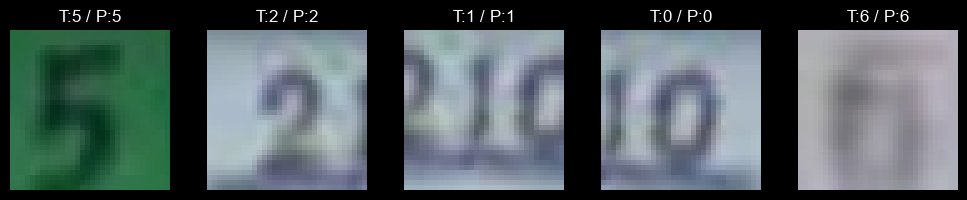

In [133]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
 img = test_images[i].permute(1, 2, 0)
 axes[i].imshow(img)
 axes[i].set_title(
 f"T:{test_labels[i].item()} / P:{predictions[i].item()}"
 )
 axes[i].axis("off")
plt.tight_layout()
plt.show()

In [130]:
image = test_images[0].unsqueeze(0)
with torch.no_grad():
 feature_maps = model.conv1(image)
print(feature_maps.shape)

torch.Size([1, 16, 32, 32])


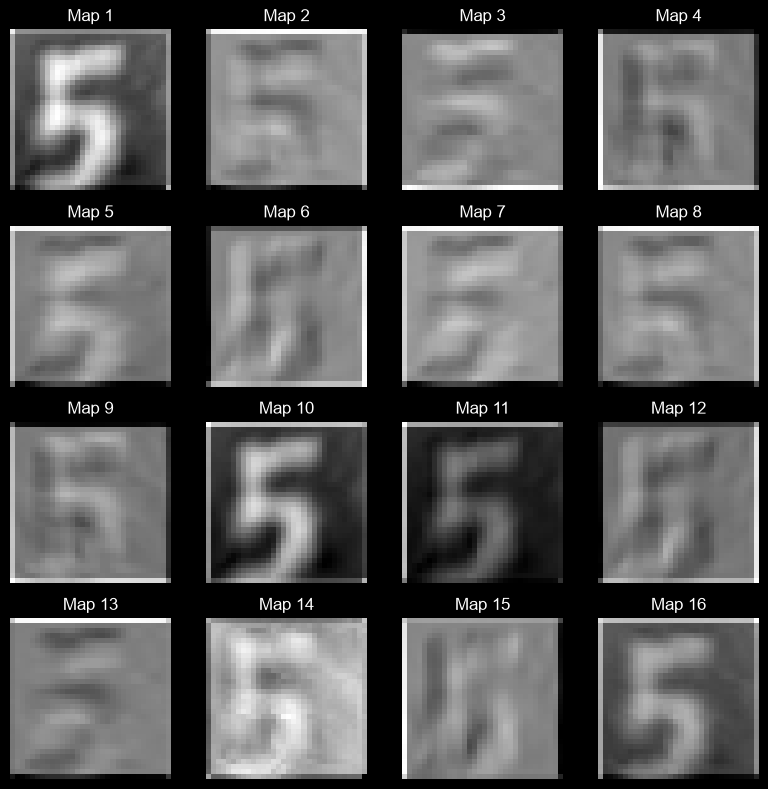

In [139]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
 ax.imshow(
 feature_maps[0, i].cpu(),
 cmap="gray"
 )
 ax.set_title(f"Map {i+1}")
 ax.axis("off")
plt.tight_layout()
plt.show()

In [126]:
# model2 = CNN()
#
# criterion = nn.CrossEntropyLoss()
#
# optimizer = torch.optim.Adam(
#   model2.parameters(),
#   lr=0.001
# )
#
# epochs = [0, 1, 2, 3, 4]
#
# for epoch in epochs:
#
#   model2.train()
#   total_loss = 0
#
#   for images, labels in train_loader:
#     optimizer.zero_grad()
#
#     outputs = model2(images)
#
#     loss = criterion(outputs, labels)
#
#     loss.backward()
#     optimizer.step()
#
#     total_loss += loss.item()
#
#   avg_loss = total_loss / len(train_loader)
#
#   print(
#     f"Epoch [{epoch + 1}/{len(epochs)}] "
#     f"Loss: {avg_loss:.4f}"
#   )
#


Epoch [1/5] Loss: 1.2106
Epoch [2/5] Loss: 0.6104
Epoch [3/5] Loss: 0.5430
Epoch [4/5] Loss: 0.5085
Epoch [5/5] Loss: 0.4835
